In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Failed to load image Python extension"
)

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

#import torchvision
from torchvision import models
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

from models.covidnet2 import CovidNet
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from models.gradcam import GradCAM
from models.gradcam import show_gradcam

import random

print("Opération terminée")

Opération terminée


1. Chargement des images

In [3]:
chemin="/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_split"

def display_directory_structure_limited(root_dir, max_files=3):
    for root, dirs, files in os.walk(root_dir):
        level = root.replace(root_dir, '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        sub_indent = ' ' * 4 * (level + 1)
        for i, f in enumerate(files):
            if i < max_files:
                print(f"{sub_indent}{f}")
            else:
                print(f"{sub_indent}...")
                break


print(display_directory_structure_limited(chemin))



COVID-19_Radiography_Dataset_split/
    .DS_Store
    test/
        .DS_Store
        Viral Pneumonia/
            Viral Pneumonia-770.png
            Viral Pneumonia-599.png
            Viral Pneumonia-15.png
            ...
        Lung_Opacity/
            Lung_Opacity-3111.png
            Lung_Opacity-2233.png
            Lung_Opacity-1048.png
            ...
        Normal/
            Normal-1821.png
            Normal-3788.png
            Normal-950.png
            ...
        COVID/
            COVID-790.png
            COVID-1405.png
            COVID-2642.png
            ...
    train/
        Viral Pneumonia/
            Viral Pneumonia-1186.png
            Viral Pneumonia-764.png
            Viral Pneumonia-994.png
            ...
        Lung_Opacity/
            Lung_Opacity-129.png
            Lung_Opacity-1060.png
            Lung_Opacity-2569.png
            ...
        Normal/
            Normal-6196.png
            Normal-7288.png
            Normal-4781.png
        

Calcul de la moyenne et de l'écart-type des images

In [4]:
transform_stats=transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_set_stat=datasets.ImageFolder(chemin+"/train_augmented", transform_stats)

train_loader_stats=DataLoader(train_set_stat, batch_size=32, shuffle=False)

In [5]:
n_pixels = 0
sum_pixels = 0.0
sum_squared_pixels = 0.0

for images, _ in train_loader_stats:

    images = images.float()

    n_pixels += images.numel()

    sum_pixels += images.sum()

    sum_squared_pixels += (images ** 2).sum()

mean = sum_pixels / n_pixels
std = torch.sqrt(sum_squared_pixels / n_pixels - mean ** 2)

print(f"Moyenne des pixels : {mean.item():.6f}")
print(f"Écart-type  : {std.item():.6f}")

Moyenne des pixels : 0.163942
Écart-type  : 0.242781


Chargement des images du jeu de données en vue de l'entraînement du modèle

In [6]:
transform=transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
   transforms.Normalize(
   mean=[mean],
    std=[std]
)
])

train_set=datasets.ImageFolder(chemin+"/train_augmented", transform=transform)
test_set=datasets.ImageFolder(chemin+"/test", transform=transform)
val_set=datasets.ImageFolder(chemin+"/validation", transform=transform)

train_loader=DataLoader(train_set, batch_size=32, shuffle=True, num_workers=4)
test_loader=DataLoader(test_set, batch_size=32, shuffle=True, num_workers=4)
val_loader=DataLoader(val_set, batch_size=32, shuffle=True, num_workers=4)

In [7]:
classes=train_set.class_to_idx
print(classes)

{'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}


2. Visualisation du jeu de données

Shape X : torch.Size([32, 1, 224, 224])
Shape y : torch.Size([32])
Moyenne : -0.0052
Écart-type : 0.9944


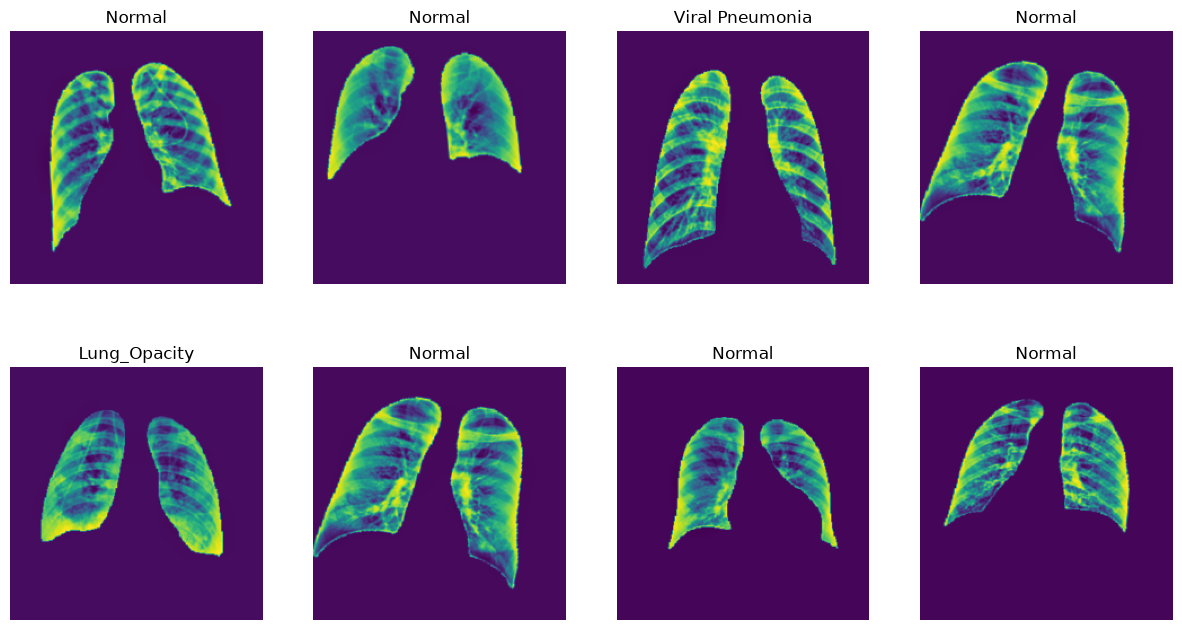

In [8]:
X_t, y_t = next(iter(train_loader))
print(f"Shape X : {X_t.shape}")
print(f"Shape y : {y_t.shape}")
print(f"Moyenne : {X_t.mean():.4f}")
print(f"Écart-type : {X_t.std():.4f}")
plt.figure(figsize=(15,8))
j=1
for i in np.random.randint(0, len(X_t), size=[8]):
    plt.subplot(2,4,j)
    plt.axis('off')
    im = X_t[i].permute(1, 2, 0)
    im = (im - im.min())/(im.max()-im.min())
    plt.imshow(im)
    plt.title(train_set.classes[y_t[i].item()])
    j+=1

3. Chargement du modèle

In [9]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
   device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)


mps


In [10]:
model = CovidNet(num_classes=4).to(device)
model

CovidNet(
  (stem): Stem(
    (stem): Sequential(
      (0): ConvBNReLU(
        (block): Sequential(
          (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
        )
      )
      (1): ConvBNReLU(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
        )
      )
      (2): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
  )
  (stage1): Sequential(
    (0): ResidualPEPX(
      (pepx): PEPX(
        (pepx): Sequential(
          (0): PointwiseConv(
            (block): ConvBNReLU(
              (block): Sequential(
                (0): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (1)

In [11]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Nombre de paramètres : {total_params:,}")
print(f"Paramètres entraînables : {trainable_params:,}")

Nombre de paramètres : 3,127,270
Paramètres entraînables : 3,127,270


4. Définition de la fonction de perte

In [12]:

criterion=nn.CrossEntropyLoss()


#Test de la fonction de perte

X_batch, y_batch = next(iter(train_loader))

X_batch=X_batch.to(device)
y_batch=y_batch.to(device)

y_pred=model(X_batch)

print(criterion(y_pred, y_batch))

tensor(1.2452, device='mps:0', grad_fn=<NllLossBackward0>)


5. Définition de l'optimizer

In [13]:
optimizer=optim.Adam(model.parameters(), 1e-4)

6. Mise en place d'un scheduler et d'un historique

In [14]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "precision": [],
    "recall": [],
    "f1": [],

    "lr": []

}

In [15]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                       mode="min",
                                                       factor=0.5,
                                                       patience=2,
                                                       min_lr=1e-6
                                                      )

In [16]:
#Pour le Early stopping

best_loss = float("inf")
best_f1 = 0.0
patience = 5
counter = 0
min_delta = 1e-3

7. Création d'une fonction d'évaluation

In [17]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0

    y_true = []
    y_pred = []

    with torch.no_grad():

        for X, y in loader:

            X = X.to(device)
            y = y.to(device)

            outputs = model(X)

            loss = criterion(outputs, y)

            running_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    loss = running_loss / len(loader)

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {"loss":loss, "accuracy":accuracy, "precision":precision, "recall":recall, "f1":f1, "y_true":y_true, "y_pred":y_pred}

7. Entraînement du modèle

In [18]:
epochs=30

torch.autograd.set_detect_anomaly(True)

best_accuracy = 0

for iterations in range (epochs):
    model.train()

    loss_total=0
    correct=0
    total=0

    progress_bar = tqdm(
            train_loader, desc="Epoch {:1d}".format(iterations), leave=True, disable=False
        )
    for i, batch in enumerate(progress_bar):
        X_batch, y_batch=batch

        X_batch=X_batch.to(device)
        y_batch=y_batch.to(device)

        optimizer.zero_grad()
        
        sorties=model(X_batch)

        loss=criterion(sorties, y_batch)
        loss.backward()

        loss_total= loss_total + loss.item()

        predictions = torch.argmax(sorties, dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)
        train_accuracy = correct / total

        optimizer.step()

        progress_bar.set_postfix(
            {
                "training_loss": "{:.3f}".format(loss_total/(i+1)),
                "acc": "{:.3f}".format(train_accuracy)
            })

    val_metrics=evaluate(model, val_loader, criterion, device)
    
    scheduler.step(val_metrics["loss"])
    
    history["train_loss"].append(loss_total / len (train_loader))
    history["val_loss"].append(val_metrics["loss"])
    history["train_acc"].append(train_accuracy)
    history["val_acc"].append(val_metrics["accuracy"])
    history["precision"].append(val_metrics["precision"])
    history["recall"].append(val_metrics["recall"])
    history["f1"].append(val_metrics["f1"])
    history["lr"].append(optimizer.param_groups[0]["lr"])

    print(f"Epoch : {iterations + 1} :\n train loss : {loss_total / len (train_loader):.4f}, val loss : {val_metrics['loss']:.4f} \n train accuracy : {train_accuracy:.4f}, val accuracy : {val_metrics['accuracy']:.4f} \n F1-score : {val_metrics['f1']:.4f}")

    if val_metrics["f1"] > best_f1:
        best_f1 = val_metrics["f1"]
        torch.save({
            "epoch": iterations + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_f1": best_f1,
            "history": history},"Covidnet_V2_best.pth")
        print("✔ Modèle sauvegardé")

    if val_metrics["loss"] < best_loss - min_delta:
        best_loss = val_metrics["loss"]
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break



Epoch 0: 100%|█| 1042/1042 [19:49<00:00,  1.14s/it, training_loss=0.773, acc=0.


Epoch : 1 :
 train loss : 0.7732, val loss : 0.6164 
 train accuracy : 0.6968, val accuracy : 0.7590 
 F1-score : 0.7572
✔ Modèle sauvegardé


Epoch 1: 100%|█| 1042/1042 [19:31<00:00,  1.12s/it, training_loss=0.586, acc=0.


Epoch : 2 :
 train loss : 0.5860, val loss : 0.5579 
 train accuracy : 0.7716, val accuracy : 0.7849 
 F1-score : 0.7888
✔ Modèle sauvegardé


Epoch 2: 100%|█| 1042/1042 [20:27<00:00,  1.18s/it, training_loss=0.515, acc=0.


...

Epoch : 8 :
 train loss : 0.3134, val loss : 0.4809 
 train accuracy : 0.8809, val accuracy : 0.8325 
 F1-score : 0.8257


Epoch 8: 100%|█| 1042/1042 [20:46<00:00,  1.20s/it, training_loss=0.218, acc=0.


Epoch : 9 :
 train loss : 0.2182, val loss : 0.4753 
 train accuracy : 0.9213, val accuracy : 0.8541 
 F1-score : 0.8488
✔ Modèle sauvegardé


Epoch 9: 100%|█| 1042/1042 [19:22<00:00,  1.12s/it, training_loss=0.150, acc=0.


Epoch : 10 :
 train loss : 0.1495, val loss : 0.5143 
 train accuracy : 0.9483, val accuracy : 0.8454 
 F1-score : 0.8385
Early stopping


7. Évaluation du modèle sur l'ensemble de test

In [21]:
model = CovidNet(
    num_classes=4,
    dropout=0.3
).to(device)

# Chargement du checkpoint
checkpoint = torch.load(
    "CovidNet_V2_best.pth",
    map_location=device
)

# Chargement des poids
model.load_state_dict(
    checkpoint["model_state_dict"]
)

metrics=evaluate(model, test_loader, criterion, device)


print(f"Loss: {metrics['loss']}")
print(f"Accuracy : {metrics['accuracy']}")
print(f"Precision : {metrics['precision']}")
print(f"recall : {metrics['recall']}")
print(f"f1 : {metrics['f1']}")


Loss: 0.40374397384849464
Accuracy : 0.8642034548944337
Precision : 0.8660845388395335
recall : 0.8642034548944337
f1 : 0.8609837447081349


dict_keys(['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia'])


,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,209,56,72,0
Lung_Opacity,16,538,45,0
Normal,16,67,929,2
Viral Pneumonia,0,3,6,125


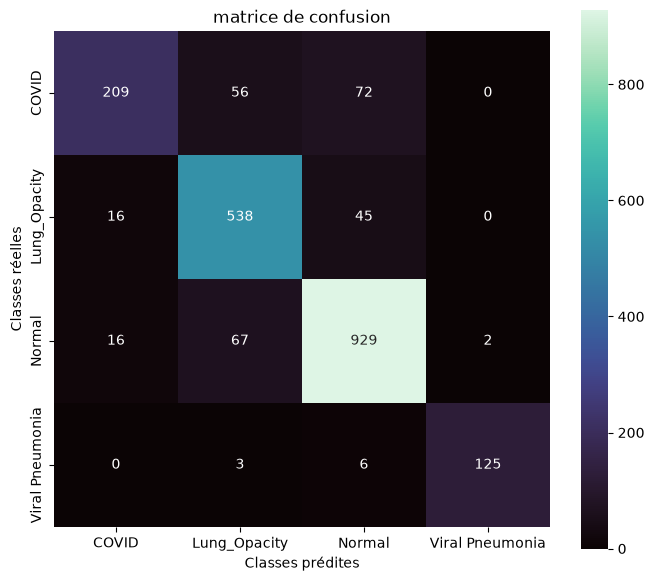

In [22]:
labels=train_set.class_to_idx.keys()
print(labels)

cm=pd.crosstab(metrics["y_true"], metrics["y_pred"], colnames=["Classes prédites"], rownames=["Classes réelles"])
cm.index=labels
cm.columns=labels

display(cm)

figure_1=plt.figure(figsize=(8,7))

sns.heatmap(cm, annot=True, square=True, fmt="d", cmap="mako")

plt.ylabel('Classes réelles')
plt.xlabel('Classes prédites')

plt.title("matrice de confusion")

plt.show()

In [29]:
import os

os.makedirs("predictions", exist_ok=True)
y_true_list, y_prob_list = [], []
with torch.no_grad():
    for X, y in test_loader:
        probs = torch.softmax(model(X.to(device)), dim=1)
        y_true_list.extend(y.numpy())
        y_prob_list.extend(probs.cpu().numpy())
np.save("predictions/y_true_test_covidnet.npy", np.array(y_true_list))
np.save("predictions/y_prob_test_covidnet.npy", np.array(y_prob_list))
print("Sauvegardé : y_true_test_covidnet.npy, y_prob_test_covidnet.npy")

Sauvegardé : y_true_test_covidnet.npy, y_prob_test_covidnet.npy


In [25]:
history=checkpoint["history"]

print("train_acc", history["train_acc"], "\n")
print("val_acc", history["val_acc"], "\n")

print("f1 score", history["f1"], "\n")

print("train_loss", history["train_loss"], "\n")
print("val_loss", history["val_loss"], "\n")

print("precision", history["precision"], "\n")
print("recall", history["recall"], "\n")

train_acc [0.6968442524598032, 0.771598272138229, 0.7990760739140869, 0.8209743220542357, 0.8361231101511879, 0.8508819294456443, 0.8664506839452844, 0.880939524838013, 0.9212562994960403] 

val_acc [0.7590014402304369, 0.7849255880940951, 0.7873259721555449, 0.8022083533365338, 0.829092654824772, 0.8098895823331733, 0.7849255880940951, 0.8324531925108017, 0.8540566490638503] 

f1 score [0.7572006092751234, 0.7888307329314784, 0.7672477658336865, 0.7991202016645191, 0.8261907915994899, 0.7888807517901577, 0.7947178682992837, 0.8256676481518432, 0.8488318004172221] 

train_loss [0.7731548771119163, 0.5860202548142358, 0.5150193988619062, 0.4634681188156417, 0.4252796700428063, 0.3887487497259353, 0.34967778470088334, 0.31343951067688824, 0.2182233312994871] 

val_loss [0.6164112452304724, 0.5578646876595237, 0.5503613982688297, 0.5006522944930828, 0.4699512921047933, 0.5327714692349687, 0.5760570105278131, 0.48091500783056923, 0.4752697725639199] 

precision [0.7687139282972849, 0.79665

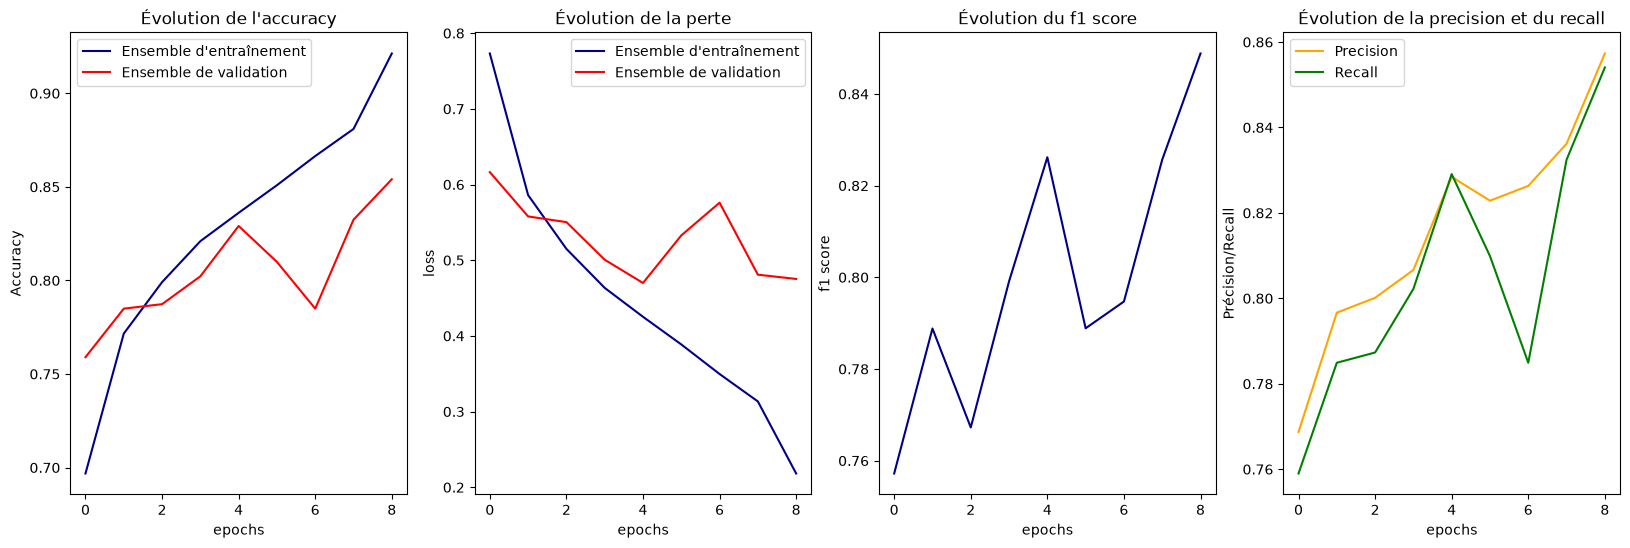

In [26]:
epochs=len(history["train_acc"])

fig=plt.figure(figsize=(20,6))

ax1=plt.subplot(1,4,1)

ax1.plot(np.arange(epochs), history["train_acc"], color="darkblue", label="Ensemble d'entraînement")
ax1.plot(np.arange(epochs), history["val_acc"], color="red", label="Ensemble de validation")

plt.xlabel("epochs")
plt.ylabel("Accuracy")
plt.title("Évolution de l'accuracy")
plt.legend()

ax2=plt.subplot(1,4,2)

ax2.plot(np.arange(epochs), history["train_loss"], color="darkblue", label="Ensemble d'entraînement")
ax2.plot(np.arange(epochs), history["val_loss"], color="red", label="Ensemble de validation")

plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Évolution de la perte")
plt.legend()

ax3=plt.subplot(1,4,3)

ax3.plot(np.arange(epochs), history["f1"], color="darkblue")

plt.xlabel("epochs")
plt.ylabel("f1 score")
plt.title("Évolution du f1 score")

ax4=plt.subplot(1,4,4)

ax4.plot(np.arange(epochs), history["precision"], color="orange", label="Precision")
ax4.plot(np.arange(epochs), history["recall"], color="green", label="Recall")


plt.xlabel("epochs")
plt.ylabel("Précision/Recall")
plt.title("Évolution de la precision et du recall")
plt.legend()

plt.show()

Grad cam

In [27]:
classes = {
    0: "COVID",
    1: "Lung Opacity",
    2: "Normal",
    3: "Viral Pneumonia"
}

def select_one_image_per_class(dataset):

    indices = {}

    for idx in range(len(dataset)):

        _, label = dataset[idx]

        if label not in indices:
            indices[label] = []

        indices[label].append(idx)

    selected = {}

    for label in indices:

        selected[label] = random.choice(indices[label])

    return selected

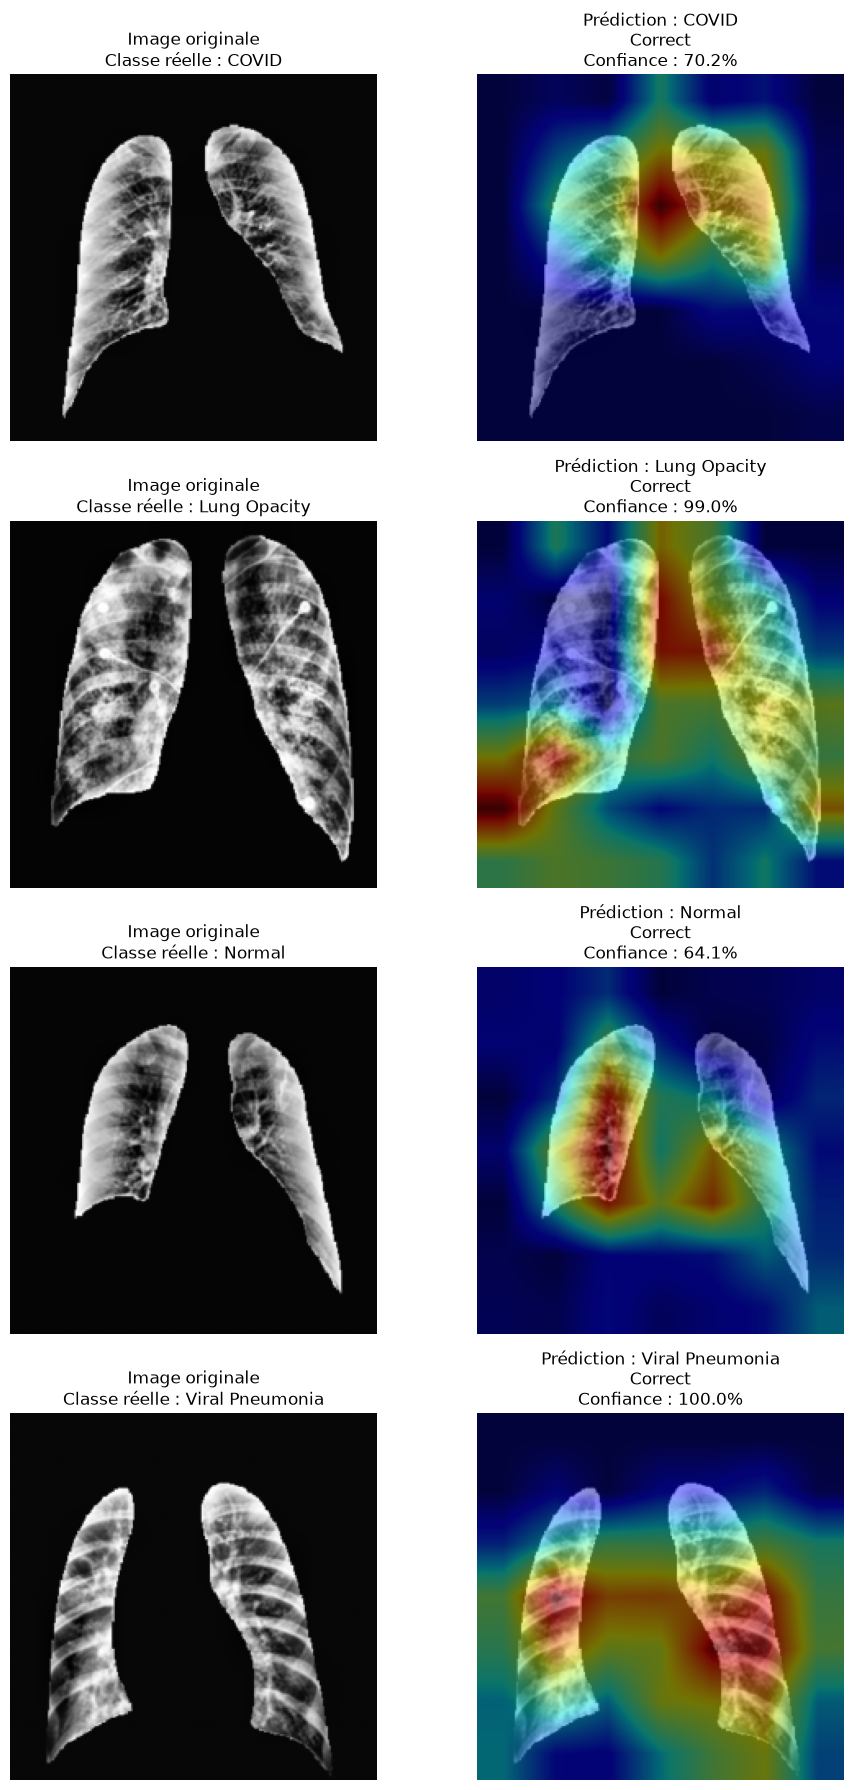

In [30]:
selected = select_one_image_per_class(test_set)

cam = GradCAM(
    model,
    model.stage4[-1]
)

fig, axes = plt.subplots(4,2, figsize=(10,18))

for row, label in enumerate(sorted(selected.keys())):

    image, target = test_set[selected[label]]

    input_tensor = image.unsqueeze(0).to(device)

    heatmap, pred, conf = cam.generate(input_tensor)

    if pred == target:
        status = "Correct"
    else:
        status = "Incorrect"
    
    image_np = image.squeeze().cpu().numpy()

    axes[row,0].imshow(image_np, cmap="gray")

    axes[row,0].set_title(
        f"Image originale\nClasse réelle : {classes[target]}"
    )

    axes[row,0].axis("off")

    axes[row,1].imshow(image_np, cmap="gray")

    axes[row,1].imshow(
        heatmap,
        cmap="jet",
        alpha=0.45
    )

    axes[row,1].set_title(
        f"Prédiction : {classes[pred]}\n{status}\nConfiance : {conf:.1%}"
    )

    axes[row,1].axis("off")

plt.tight_layout()

plt.show()

10. Calcul des prédictions

In [32]:
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device)

        outputs = model(X)

        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu())

        all_preds.append(torch.argmax(probs, dim=1).cpu())

        all_labels.append(y.cpu())

all_probs = torch.cat(all_probs)
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

In [33]:
df = pd.DataFrame({
    "Classe réelle": all_labels.numpy(),
    "Classe prédite": all_preds.numpy(),
    "P(COVID)": all_probs[:,0].numpy(),
    "P(Lung Opacity)": all_probs[:,1].numpy(),
    "P(Normal)": all_probs[:,2].numpy(),
    "P(Viral Pneumonia)": all_probs[:,3].numpy()
})

display(df.head())

,Classe réelle,Classe prédite,P(COVID),P(Lung Opacity),P(Normal),P(Viral Pneumonia)
0,2,2,0.000901,0.001078,0.997992,0.000030
1,1,1,0.065420,0.720316,0.207920,0.006344
2,1,1,0.001994,0.991006,0.006983,0.000018
3,1,1,0.000820,0.957334,0.001397,0.040449
4,0,0,0.878152,0.099195,0.022316,0.000337


In [34]:
df_history=pd.DataFrame(history)
display(df_history)

,train_loss,val_loss,train_acc,val_acc,precision,recall,f1,lr
0,0.773155,0.616411,0.696844,0.759001,0.768714,0.759001,0.757201,0.00010
1,0.586020,0.557865,0.771598,0.784926,0.796652,0.784926,0.788831,0.00010
2,0.515019,0.550361,0.799076,0.787326,0.800130,0.787326,0.767248,0.00010
3,0.463468,0.500652,0.820974,0.802208,0.806649,0.802208,0.799120,0.00010
4,0.425280,0.469951,0.836123,0.829093,0.828434,0.829093,0.826191,0.00010
5,0.388749,0.532771,0.850882,0.809890,0.822864,0.809890,0.788881,0.00010
6,0.349678,0.576057,0.866451,0.784926,0.826324,0.784926,0.794718,0.00010
7,0.313440,0.480915,0.880940,0.832453,0.836201,0.832453,0.825668,0.00005
8,0.218223,0.475270,0.921256,0.854057,0.857319,0.854057,0.848832,0.00005
